In [1]:
%matplotlib inline 
 
# 1) Wipe out your namespace
%reset -f

# 2) Clear Jupyter’s stored outputs (and inputs if you like)
try:
    Out.clear()
except NameError:
    pass

try:
    In.clear()
except NameError:
    pass

# 3) Force Python GC
import gc
gc.collect()

# 4) Free any GPU buffers
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

import importlib
from libs import params, preps, feats, plots, models_core, models_custom
importlib.reload(params)
importlib.reload(preps)
importlib.reload(feats)
importlib.reload(plots)
importlib.reload(models_core)
importlib.reload(models_custom)

<module 'libs.models_custom' from '/workspace/my_models/Trading/_Stock_Analysis_/libs/models_custom.py'>

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy  as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

import datetime as dt
import os
from typing import Sequence, List, Tuple, Optional, Union
from pathlib import Path
import time
import io
import contextlib

import torch
import torch.nn as nn
from torch.nn import MSELoss, Dropout
import torch.nn.functional as Funct
from torch_lr_finder import LRFinder
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, ReduceLROnPlateau, OneCycleLR
from torch.amp import GradScaler

from tqdm import tqdm
import h5py

from copy import deepcopy
from typing import Callable, List, Dict, Tuple, Optional
from pprint import pprint
from PIL import Image

import shap
from captum.attr import IntegratedGradients

from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.preprocessing import StandardScaler

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

from IPython.display import clear_output, display


In [3]:
df_sign_allfeats = pd.read_csv(params.sign_featall_csv, index_col=0, parse_dates=True) 
df_sign_allfeats

,atr_21_raw,adx_21_raw,rsi_21_raw,vwap_ohlc_close_session_raw,close_raw,targ_signal,signal_thresh,volume,trade_count,ret,sma_pct_5,sma_pct_9,sma_pct_21,sma_pct_50,sma_pct_100,roc_5,roc_10,roc_21,body_pct,upper_shad,lower_shad,range_pct,rsi_7,rsi_14,rsi_21,rsi_28,atr_pct_7,atr_pct_14,atr_pct_28,plus_di_7,minus_di_7,adx_7,plus_di_14,minus_di_14,adx_14,plus_di_21,minus_di_21,adx_21,plus_di_28,minus_di_28,adx_28,bb_w_20_3p0,bb_w_50_2p0,vol_spike_7,vol_spike_14,vol_spike_28,dist_high_100,dist_low_100,obv_diff_7,obv_pct_7,obv_diff_21,obv_pct_21,ret_std_21,ret_std_63,stoch_k_14_3_3,stoch_d_14_3_3,stoch_k_9_3_3,stoch_d_9_3_3,cci_14,cci_20,mfi_14,mfi_20,cmf_14,cmf_20,donch_w_20,donch_w_55,kc_w_20_20_2.0,open_RZ,high_RZ,low_RZ,vwap_RZ,bid_RZ,sma_5_RZ,sma_9_RZ,sma_21_RZ,sma_50_RZ,sma_100_RZ,ema_5_RZ,ema_9_RZ,ema_13_RZ,ema_21_RZ,ema_50_RZ,body_RZ,macd_line_6_13_5_RZ,macd_signal_6_13_5_RZ,macd_diff_6_13_5_RZ,macd_line_12_26_9_RZ,macd_signal_12_26_9_RZ,macd_diff_12_26_9_RZ,atr_7_RZ,atr_14_RZ,atr_21_RZ,atr_28_RZ,bb_lband_20_2p0_RZ,bb_hband_20_2p0_RZ,bb_lband_20_3p0_RZ,bb_hband_20_3p0_RZ,bb_lband_50_2p0_RZ,bb_hband_50_2p0_RZ,obv_RZ,rolling_max_close_100_RZ,rolling_min_close_100_RZ,donch_h_20_RZ,donch_l_20_RZ,donch_h_55_RZ,donch_l_55_RZ,roll_vwap_20_RZ,roll_vwap_50_RZ,slope_close_20_RZ,slope_close_50_RZ,kc_l_20_20_1.5_RZ,kc_h_20_20_1.5_RZ,kc_l_20_20_2.0_RZ,kc_h_20_20_2.0_RZ,vwap_ohlc_close_session_RZ,time_minute,time_hour,time_dow,time_month,time_day_of_year,time_week_of_year,time_in_sess,time_premark,time_afthour
2016-01-04 08:41:00,0.011762,58.242894,31.248657,25.919854,25.92750,0.133285,0.133285,0.003001,0.000000,0.500527,0.501077,0.511972,0.526691,0.339716,0.055294,0.506071,0.529871,0.538442,0.502366,0.0000,0.000000,0.000000,0.675776,0.351001,0.229607,0.151212,0.017683,0.097144,0.203494,0.556009,0.249345,0.193022,0.189373,0.381886,0.436306,0.103900,0.436029,0.752452,0.059443,0.470455,0.923281,0.037993,1.000000,0.262250,0.294475,0.300741,0.737961,0.089719,0.447408,0.449264,0.444670,0.428810,0.046214,1.000000,1.000000,1.000000,1.000000,1.000000,0.655434,0.666181,1.000000,0.784011,0.500120,0.500608,0.024544,0.727768,0.158989,0.469072,0.448250,0.496885,0.491038,0.469952,0.470791,0.474209,0.477315,0.476543,0.491380,0.470687,0.470643,0.471345,0.475039,0.485438,0.516129,0.483422,0.482360,0.493503,0.482112,0.485421,0.484554,0.146934,0.167009,0.176886,0.184782,0.628700,0.332373,0.705459,0.261541,0.674253,0.283577,0.321083,0.666621,0.310811,0.503818,0.434483,0.777778,0.107143,0.513778,0.516734,0.485469,0.485475,0.529554,0.418670,0.549414,0.404398,0.463061,0.299306,0.270833,0.500000,0.5,0.508219,0.500000,0.0,1.0,0.0
2016-01-04 08:42:00,0.011202,57.694835,31.248657,25.919967,25.92750,0.160400,0.146842,0.003011,0.000000,0.500527,0.501077,0.507672,0.524170,0.363764,0.063205,0.499213,0.525006,0.531102,0.502366,0.0000,0.000000,0.000000,0.675776,0.351001,0.229607,0.151212,0.014802,0.089858,0.195909,0.556009,0.249345,0.207732,0.189373,0.381886,0.421594,0.103900,0.436029,0.744330,0.059443,0.470455,0.919301,0.038165,0.957096,0.254818,0.269829,0.289415,0.737961,0.089719,0.447526,0.449461,0.444783,0.429040,0.045263,1.000000,1.000000,1.000000,1.000000,1.000000,0.639493,0.651013,1.000000,0.775197,0.500120,0.500608,0.024544,0.727768,0.150705,0.469072,0.448250,0.496885,0.491038,0.469952,0.470791,0.572559,0.575491,0.352493,0.333770,0.570397,0.569248,0.569784,0.374932,0.374711,0.516129,0.363993,0.599418,0.369664,0.598500,0.598263,0.343129,0.062259,0.078042,0.086041,0.092065,0.714156,0.412339,0.791402,0.341453,0.751257,0.213091,0.340814,0.666621,0.310811,0.503818,0.434483,0.777778,0.107143,0.634607,0.376928,0.598404,0.605422,0.633487,0.317358,0.654245,0.302405,0.571039,0.300000,0.270833,0.500000,0.5,0.508219,0.500000,0.0,1.0,0.0
2016-01-04 08:43:00,0.010788,57.235099,30.635100,25.919976,25.92500,0.214479,0.160400,0.000125,0.000000,0.472931,0.480932,0.488969,0.511969,0.381179,0.066383,0.486869,0.511388,0.517762,0.502366,0.0000,0.000000,0.000000,0.483255,0.330896,0.2215

In [4]:
# extract the kept features, excluding strategy and signal columns

strategy_cols_tick_raw = [f"{col}_raw" for col in params.strategy_cols_tick]
known_cols = set(strategy_cols_tick_raw + params.signals_cols_tick)

kept_features = [col for col in df_sign_allfeats.columns if col not in known_cols]

print(f"Kept {len(kept_features)} features.")

Kept 117 features.


In [5]:
# importlib.reload(models_core) ########

train_loader, val_loader, test_loader, end_times_tr, end_times_val, end_times_te = models_core.model_core_pipeline(
    df              = df_sign_allfeats,
    train_batch     = params.hparams["TRAIN_BATCH"],
    train_workers   = params.hparams["TRAIN_WORKERS"],
    prefetch_factor = params.hparams["TRAIN_PREFETCH_FACTOR"],
    look_back       = params.hparams["LOOK_BACK"],
    features_cols   = kept_features,
)

del df_sign_allfeats, end_times_tr, end_times_val, end_times_te
gc.collect()

Preparing days:   0%|          | 0/2520 [00:00<?, ?it/s]

N_total: 2282625 look_back: 30 F: 117
Estimated X_buf size: 32.05 GB — using RAM (in-memory) (thresh 56 GiB)


Writing days:   0%|          | 0/2520 [00:00<?, ?it/s]

Creating DayWindowDatasets:   0%|          | 0/3 [00:00<?, ?split/s]

40

In [7]:
# importlib.reload(feats)

# Save test_loader X_windows and y_windows to be reused for feature importance

# Execute the extraction
X_path, y_path, meta_path = feats.extract_and_save_windows(
    test_loader, 
    out_dir=params.models_folder, 
    features=kept_features
)

# Clean up namespace
del X_path, y_path, meta_path
gc.collect()

Streaming straight to binary:   0%|          | 0/377 [00:00<?, ?batch/s]

839

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:375: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Training sees 1776 unique trading days per epoch.

Model parameters: total=128,081, trainable=128,081

Using HyperParameters:
 {'USE_CONV': False, 'CONV_K': 3, 'CONV_DILATION': 1, 'CONV_CHANNELS': 64, 'USE_TCN': False, 'TCN_LAYERS': 1, 'TCN_KERNEL': 3, 'TCN_CHANNELS': 64, 'USE_SHORT_LSTM': False, 'SHORT_UNITS': 64, 'DROPOUT_SHORT': 0.1, 'USE_TRANSFORMER': True, 'TRANSFORMER_D_MODEL': 64, 'TRANSFORMER_LAYERS': 2, 'TRANSFORMER_HEADS': 4, 'TRANSFORMER_FF_MULT': 4, 'DROPOUT_TRANS': 0.03, 'USE_LONG_LSTM': False, 'LONG_UNITS': 64, 'DROPOUT_LONG': 0.1, 'FLATTEN_MODE': 'attn', 'PRED_HIDDEN': 96, 'ALPHA_SMOOTH': 0, 'WARMUP_STEPS': 3, 'USE_HUBER': False, 'HUBER_DELTA': 0.1, 'USE_DELTA': False, 'LAMBDA_DELTA': 0.1, 'MAX_EPOCHS': 90, 'EARLY_STOP_PATIENCE': 9, 'WEIGHT_DECAY': 2e-06, 'CLIPNORM': 2, 'ONECYCLE_MAX_LR': 0.0002, 'HEAD_LR_PCT': 1, 'ONECYCLE_DIV_FACTOR': 10, 'ONECYCLE_FINAL_DIV': 100, 'ONECYCLE_PCT_START': 0.1, 'ONECYCLE_STRATEGY': 'cos', 'TRAIN_BATCH': 16, 'VAL_BATCH': 1, 'TRAIN_WORKERS'

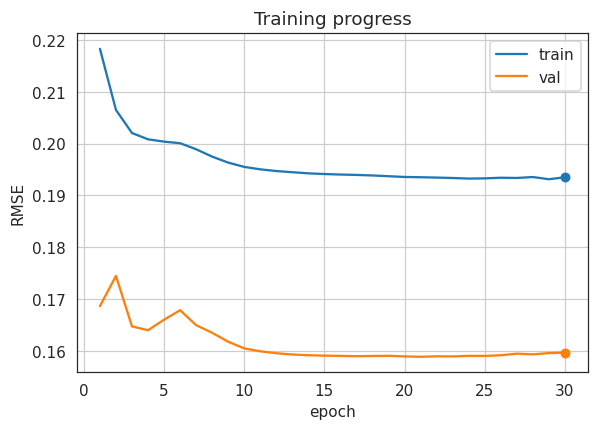

Epoch 1 ▶ Train:   0%|          | 0/111 [00:02<?, ?it/s]

eval:   0%|          | 0/367 [00:00<?, ?it/s]

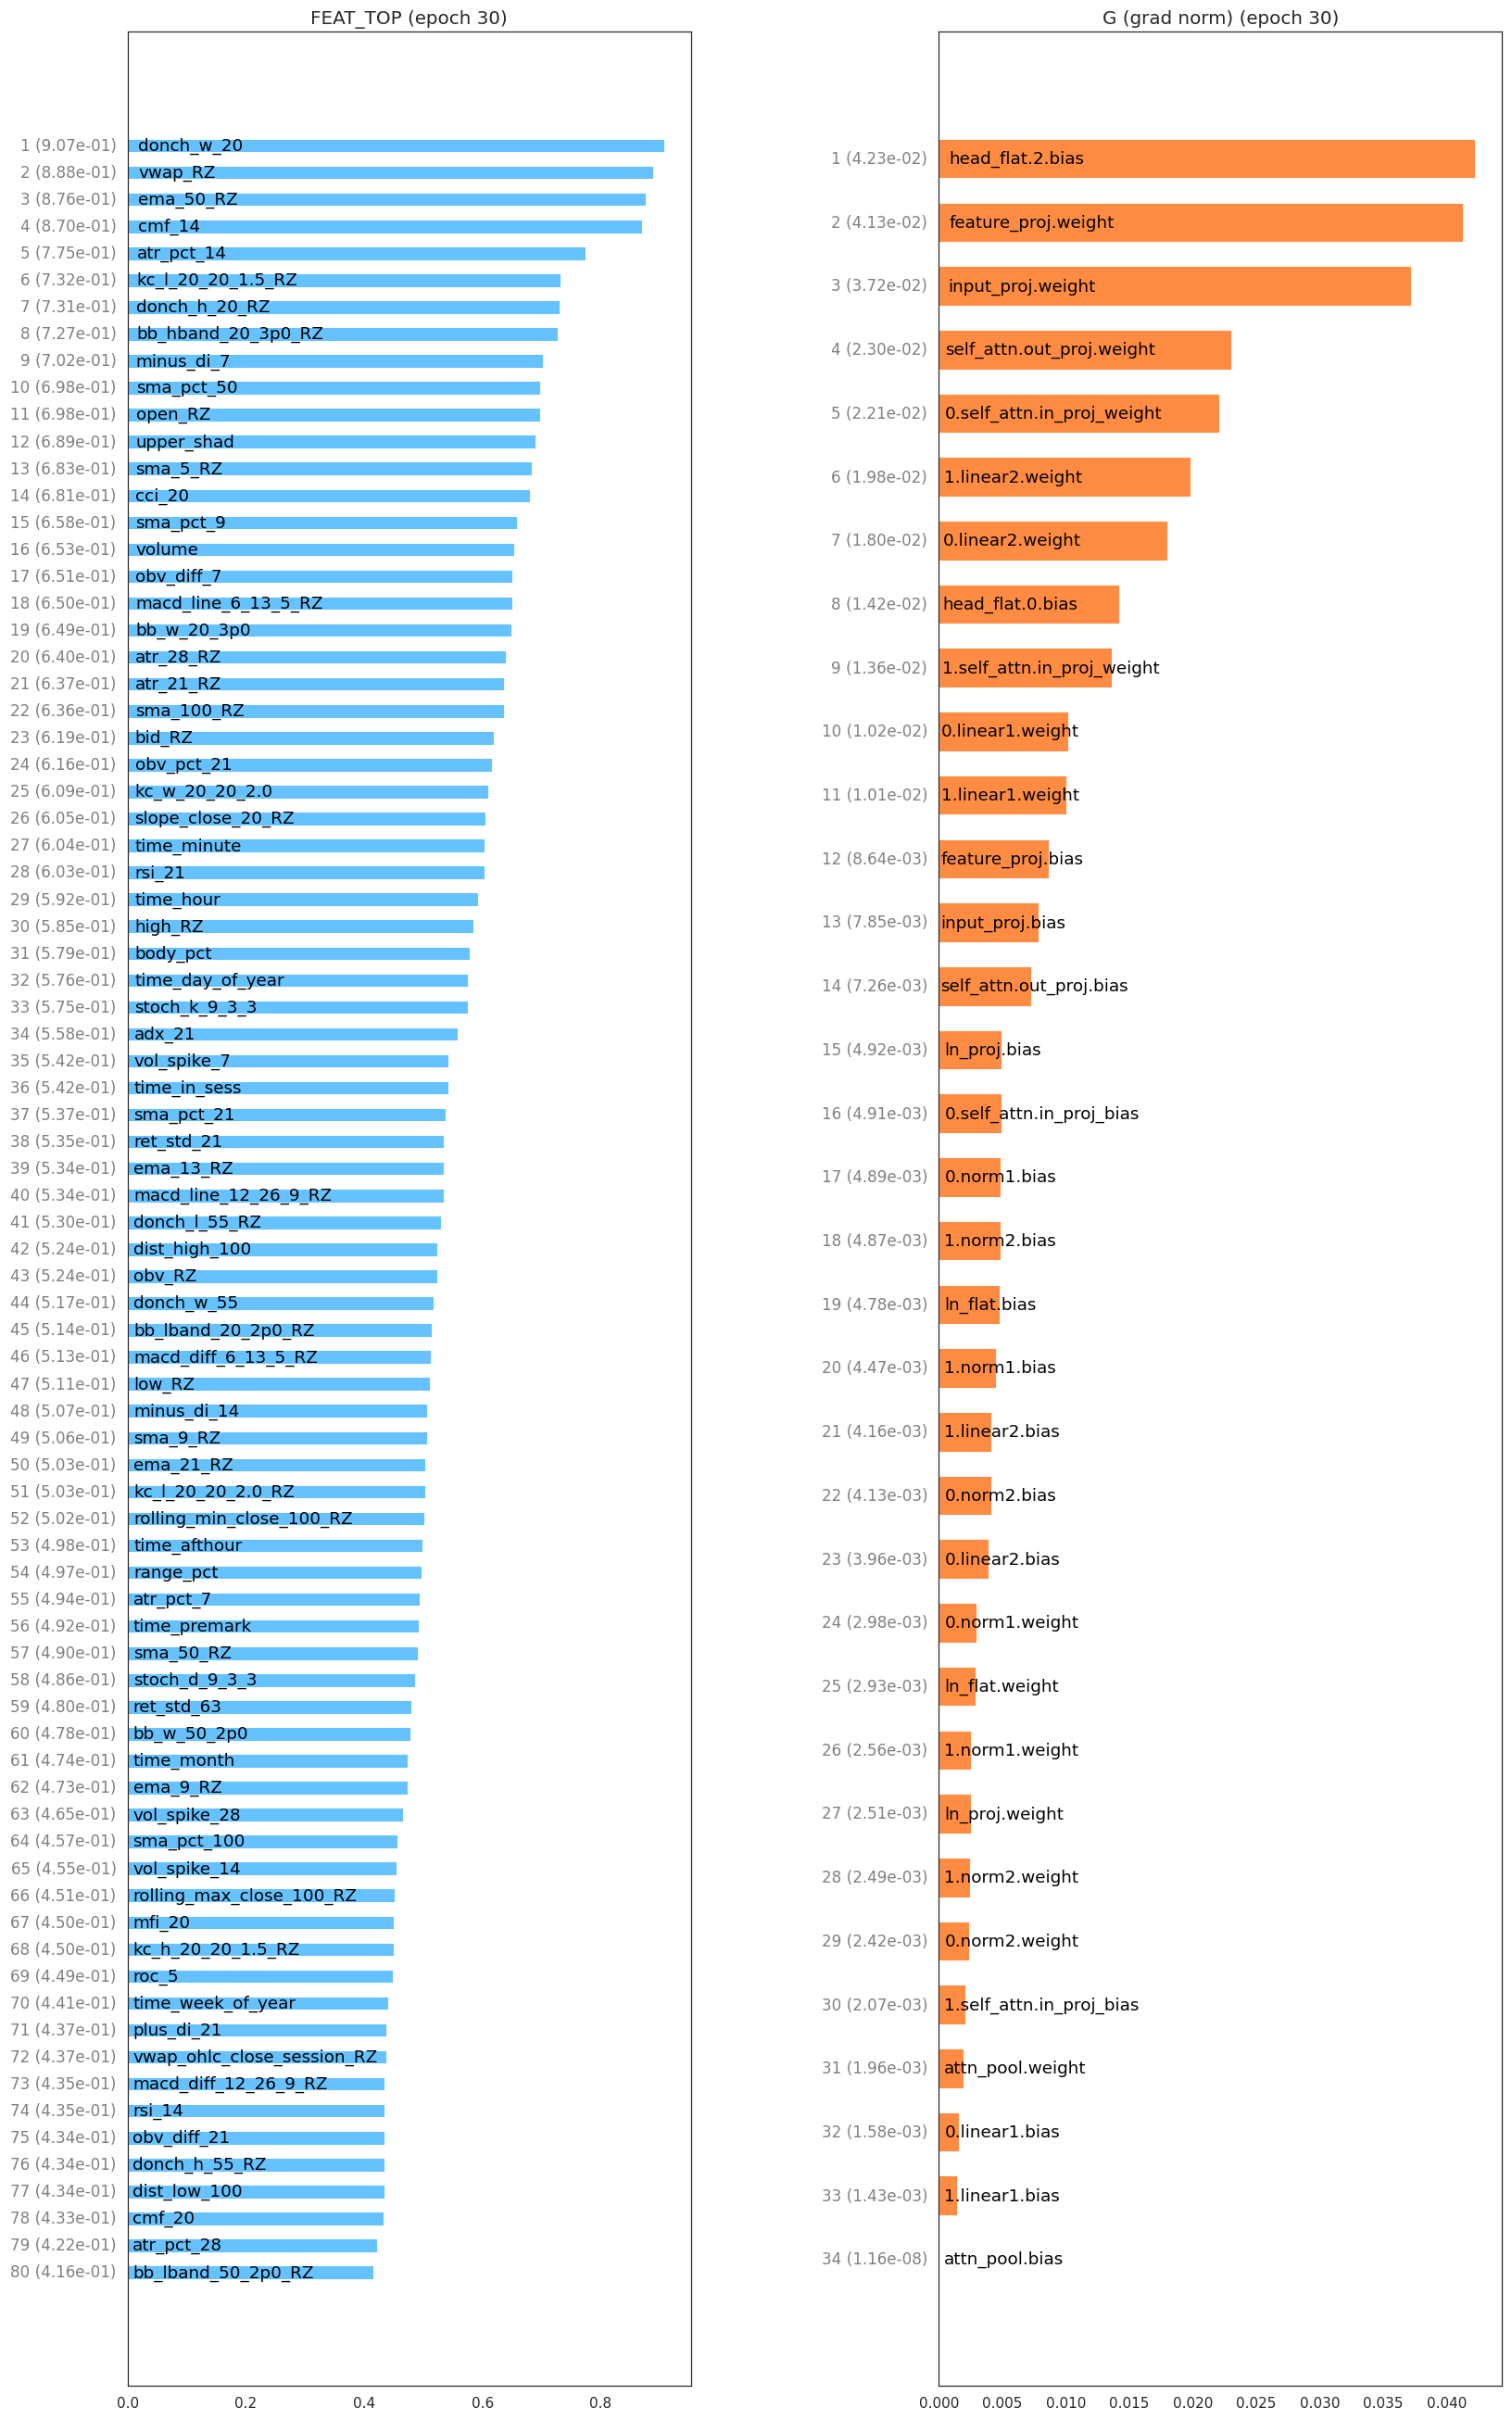

Epoch 01  TRAIN→ RMSE=0.21834, R²=-0.010 |  VALID→ RMSE=0.16863, R²=0.063 |  lr=2.54e-05 |  loss=4.75067e-02 |  improved=True


Epoch 2 ▶ Train:   0%|          | 0/111 [00:14<?, ?it/s]

eval:   0%|          | 0/367 [00:00<?, ?it/s]

Epoch 02  TRAIN→ RMSE=0.20652, R²=0.096 |  VALID→ RMSE=0.17447, R²=-0.003 |  lr=4.11e-05 |  loss=4.24926e-02 |  improved=False


Epoch 3 ▶ Train:   0%|          | 0/111 [00:00<?, ?it/s]

...

eval:   0%|          | 0/367 [00:00<?, ?it/s]

Epoch 29  TRAIN→ RMSE=0.19314, R²=0.210 |  VALID→ RMSE=0.15955, R²=0.161 |  lr=1.71e-04 |  loss=3.71605e-02 |  improved=False


Epoch 30 ▶ Train:   0%|          | 0/111 [00:00<?, ?it/s]

eval:   0%|          | 0/367 [00:00<?, ?it/s]

Epoch 30  TRAIN→ RMSE=0.19352, R²=0.207 |  VALID→ RMSE=0.15964, R²=0.160 |  lr=1.69e-04 |  loss=3.73068e-02 |  improved=False
✅ Final‐best model saved: AAPL_0.15884_all.pth


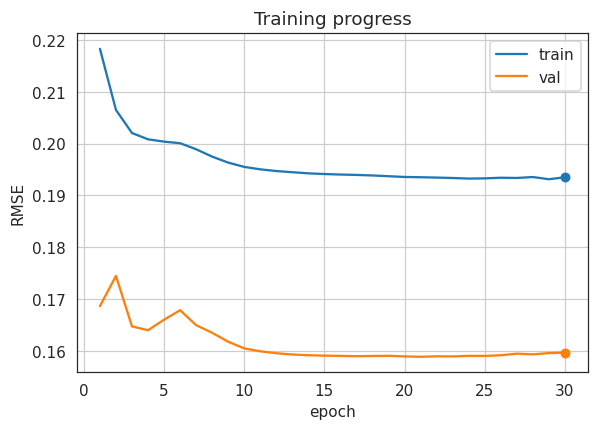

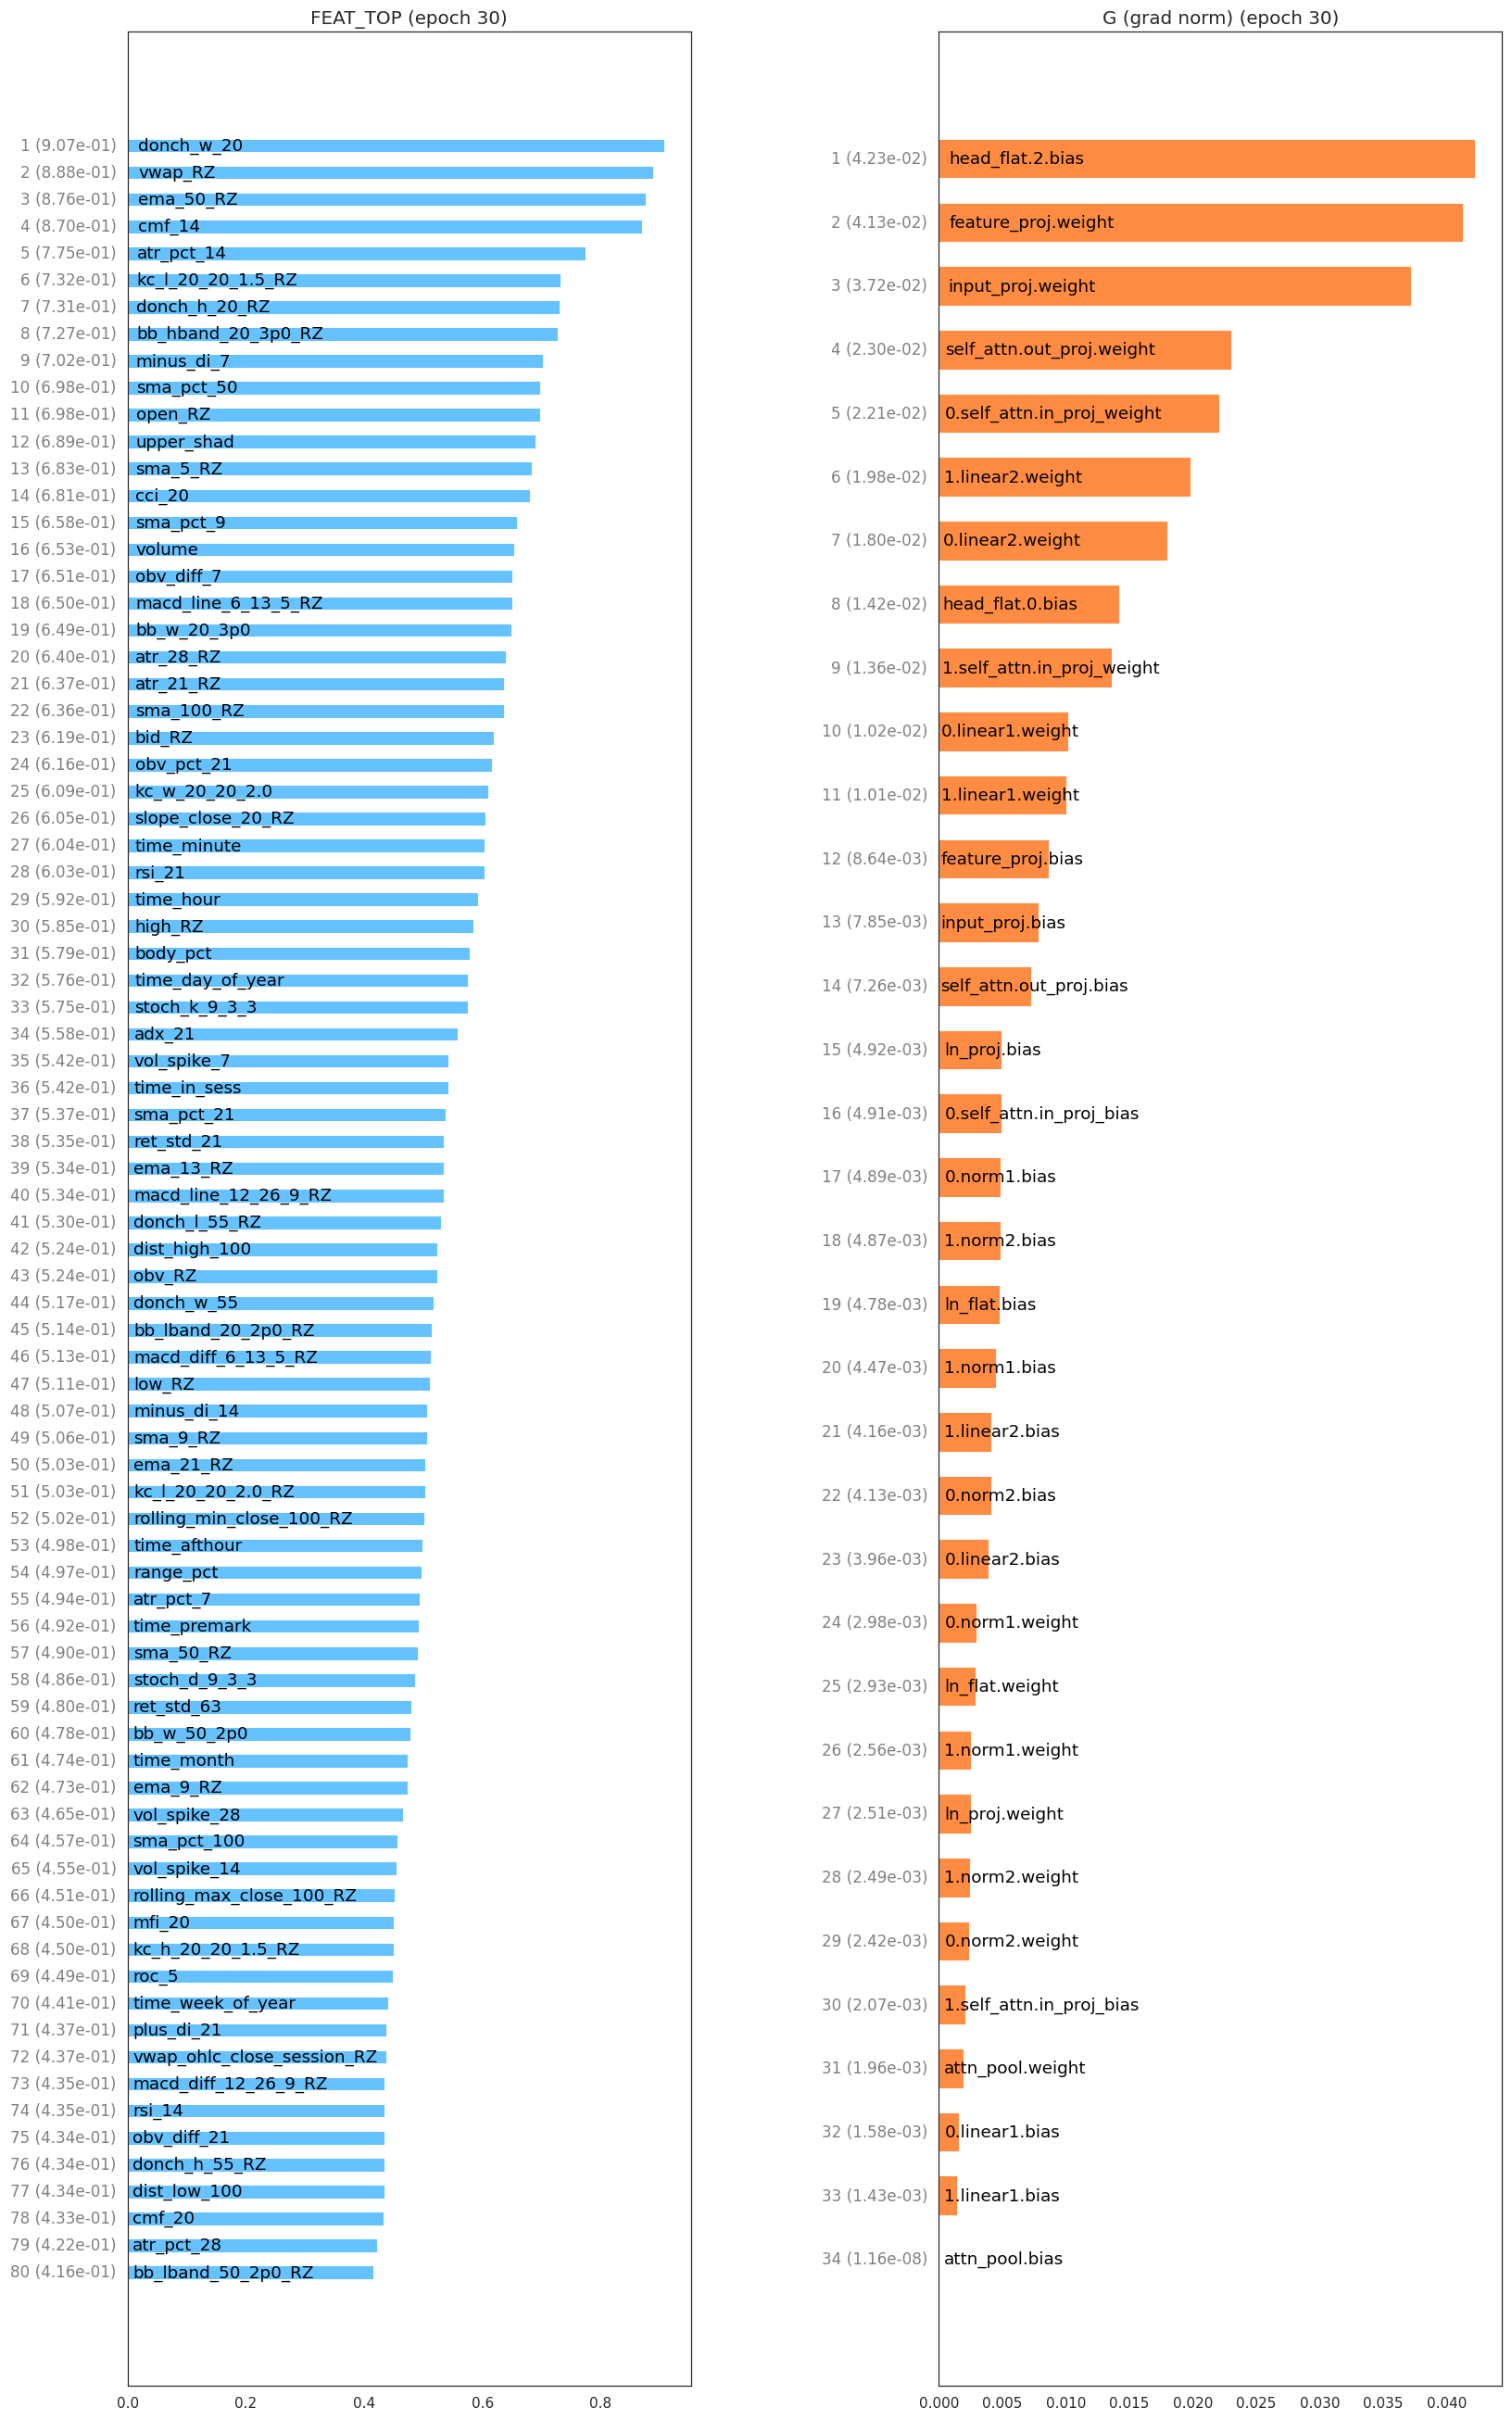

In [10]:
# importlib.reload(models_core)

#################### MODEL TRAINING #####################

model = models_custom.ModelClass(
    n_feats             = len(kept_features),
    short_units         = params.hparams["SHORT_UNITS"],
    long_units          = params.hparams["LONG_UNITS"],
    transformer_d_model = params.hparams["TRANSFORMER_D_MODEL"],
    transformer_layers  = params.hparams["TRANSFORMER_LAYERS"],
    dropout_short       = params.hparams["DROPOUT_SHORT"],
    dropout_long        = params.hparams["DROPOUT_LONG"],
    dropout_trans       = params.hparams["DROPOUT_TRANS"],
    pred_hidden         = params.hparams["PRED_HIDDEN"],
    look_back           = params.hparams["LOOK_BACK"],

    # Gating flags
    use_conv            = params.hparams["USE_CONV"],
    use_tcn             = params.hparams["USE_TCN"],
    use_short_lstm      = params.hparams["USE_SHORT_LSTM"],
    use_transformer     = params.hparams["USE_TRANSFORMER"],
    use_long_lstm       = params.hparams["USE_LONG_LSTM"],
    use_delta           = params.hparams["USE_DELTA"],
    flatten_mode        = params.hparams["FLATTEN_MODE"]
)

model.feature_names = kept_features # for logging
model.to(params.device)  
    
optimizer = AdamW(
  model.parameters(),
  lr           = params.hparams["ONECYCLE_MAX_LR"],
  weight_decay = params.hparams["WEIGHT_DECAY"]
)

batches_per_epoch = len(train_loader)
total_steps = batches_per_epoch * params.hparams["MAX_EPOCHS"]

scheduler = OneCycleLR(
  optimizer,
  max_lr           = params.hparams["ONECYCLE_MAX_LR"],
  total_steps      = total_steps,
  pct_start        = params.hparams["ONECYCLE_PCT_START"],
  div_factor       = params.hparams["ONECYCLE_DIV_FACTOR"],
  final_div_factor = params.hparams["ONECYCLE_FINAL_DIV"],
  anneal_strategy  = params.hparams["ONECYCLE_STRATEGY"],
)
optimizer.scheduler = scheduler # necessary to log sched_field

if getattr(scheduler, "total_steps", None) != total_steps:
    raise RuntimeError(f"Scheduler total_steps mismatch: scheduler={getattr(scheduler,'total_steps',None)} expected={total_steps}")

n_days = len(train_loader.dataset)
print(f"Training sees {n_days} unique trading days per epoch.\n")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: total={total_params:,}, trainable={trainable_params:,}\n")
print('Using HyperParameters:\n', params.hparams)
print('\ntorch.cuda.is_available', torch.cuda.is_available())

# -----------------------------------------------------------------------------
# Run the custom stateful training loop
# -----------------------------------------------------------------------------
best_val_rmse  = models_custom.model_training_loop(
    model               = model,
    optimizer           = optimizer,
    scheduler           = scheduler,
    scaler              = GradScaler("cuda"),
    train_loader        = train_loader,
    val_loader          = val_loader,
    all_features        = True
)


In [ ]:
# import numpy as np, pandas as pd
# df_check = df_inds_unsc  # the DataFrame you pass to training
# print("shape:", df_check.shape)
# print(df_check.replace([np.inf, -np.inf], np.nan).isna().sum().sort_values(ascending=False).head(40))
